# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/intermim/` de los datos de entrenamiento
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

Dataset cargado desde: ..\data\interim\train_set.csv
Dimensiones: 16512 filas x 10 columnas

--- Primeras filas ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -117.22     32.75                34.0       6001.0          1111.0   
1    -117.03     32.69                10.0        901.0           163.0   
2    -122.27     37.74                28.0       6909.0          1554.0   
3    -121.82     37.25                25.0       4021.0           634.0   
4    -115.98     33.32                 8.0        240.0            46.0   

   population  households  median_income  median_house_value ocean_proximity  
0      2654.0      1072.0         4.5878            291000.0      NEAR OCEAN  
1       698.0       167.0         4.6648            156100.0      NEAR OCEAN  
2      2974.0      1484.0         3.6875            353900.0        NEAR BAY  
3      2178.0       650.0         5.1663            241200.0       <1H OCEAN  
4        63.0        24.0         1.46

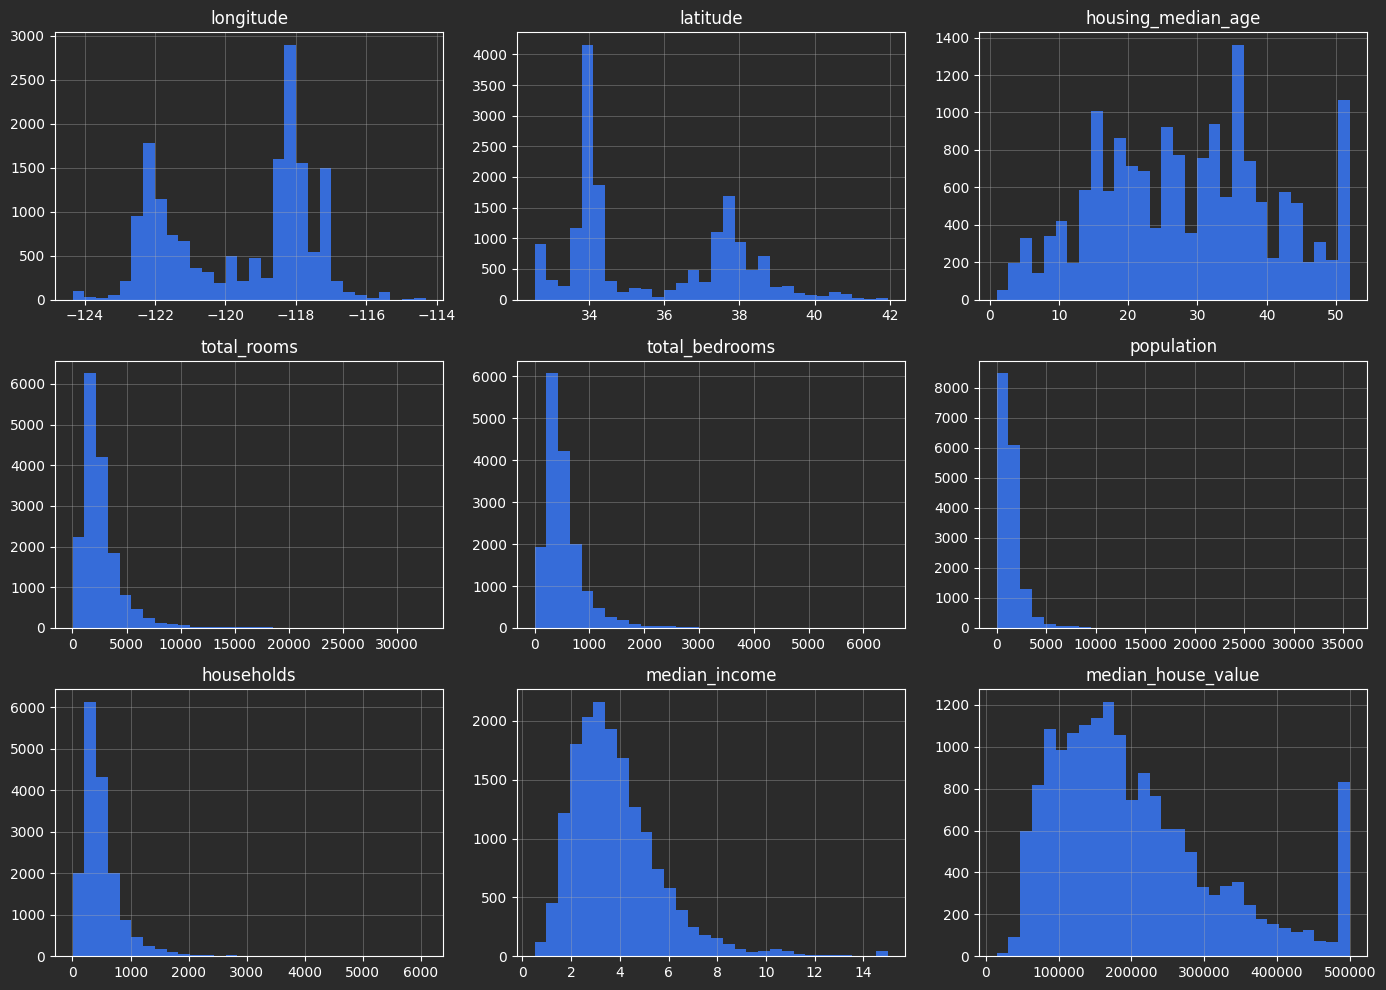

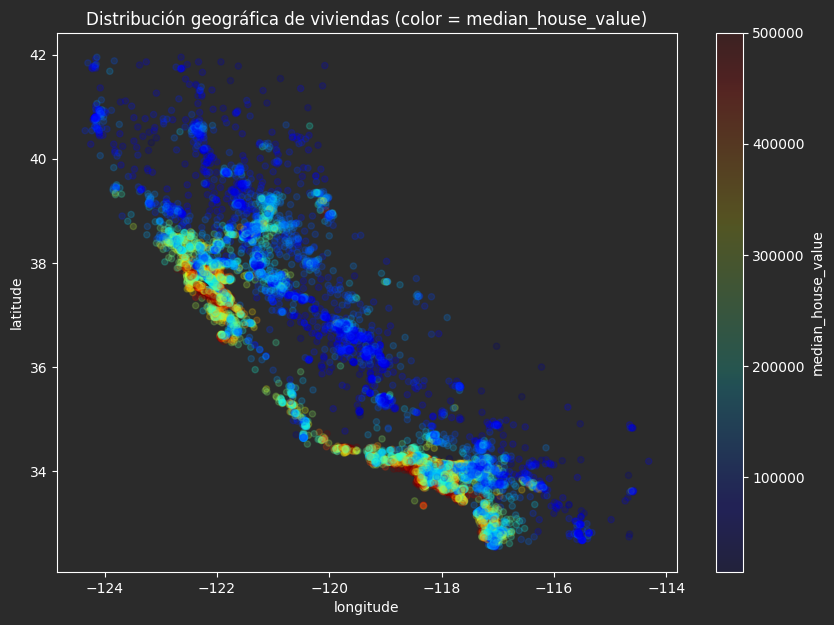


--- Correlación con median_house_value ---
median_house_value    1.000000
median_income         0.687013
total_rooms           0.134060
housing_median_age    0.104714
households            0.065798
total_bedrooms        0.049993
population           -0.025820
longitude            -0.043603
latitude             -0.146324
Name: median_house_value, dtype: float64


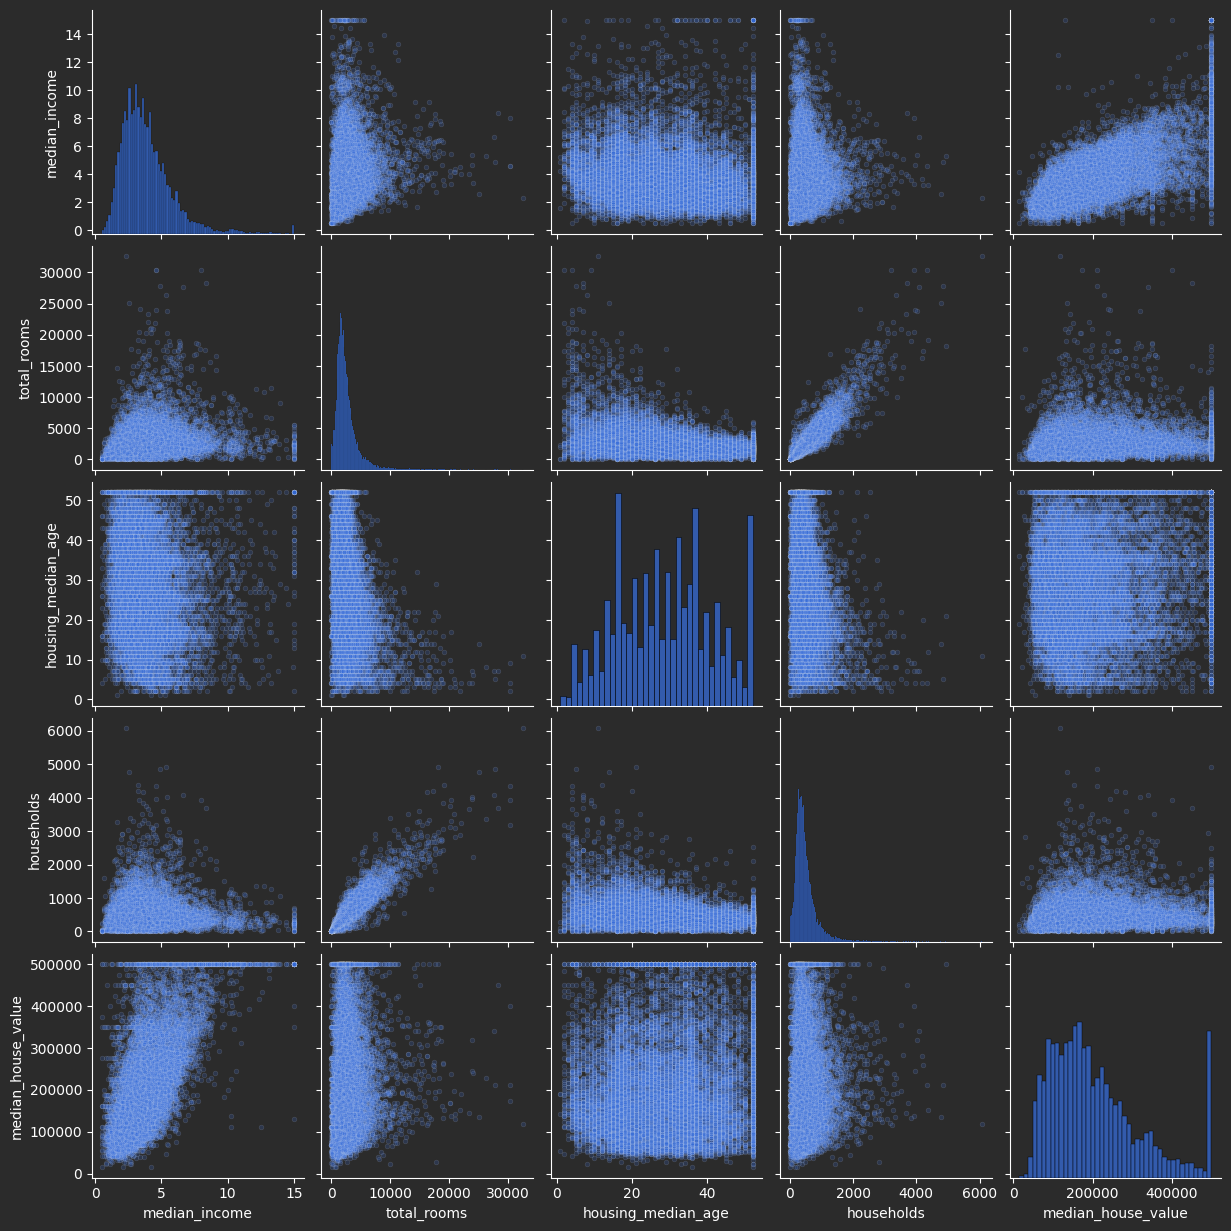


--- Distribución de ocean_proximity ---
ocean_proximity
<1H OCEAN     7313
INLAND        5276
NEAR OCEAN    2091
NEAR BAY      1827
ISLAND           5
Name: count, dtype: int64


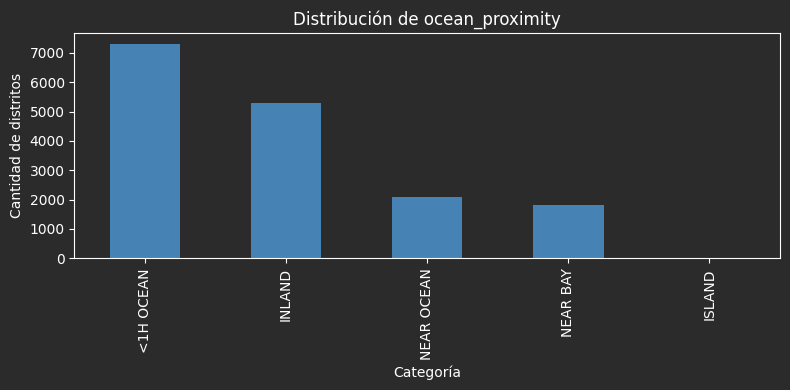


=== CONCLUSIONES DE NEGOCIO ===
1) median_income tiene la correlación más alta con el precio (0.69), siendo la variable más predictiva del dataset. Variables como total_rooms (0.13) aportan poco por sí solas.
2) El mapa geoespacial muestra clusters de alto valor en la costa (Bay Area, Los Ángeles), confirmando que la ubicación geográfica es un factor clave de precio.
3) Se detectaron outliers significativos: total_rooms (1,033 casos), total_bedrooms (1,013) y population (965). Estos deben imputarse o transformarse en la fase de feature engineering.
4) total_bedrooms tiene 163 valores faltantes (≈1% del train set). No hay duplicados. Este faltante debe imputarse antes del modelado.


In [3]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1) Carga de datos (train set)
train_path = Path("../data/interim/train_set.csv")
housing = pd.read_csv(train_path)

print(f"Dataset cargado desde: {train_path}")
print(f"Dimensiones: {housing.shape[0]} filas x {housing.shape[1]} columnas")

# 2) Inspección de estructura y calidad
print("\n--- Primeras filas ---")
print(housing.head())

print("\n--- Tipos de datos ---")
print(housing.dtypes)

print("\n--- Estadísticos descriptivos (numéricos) ---")
print(housing.describe())

print("\n--- Completitud: valores faltantes por variable ---")
missing = housing.isna().sum().sort_values(ascending=False)
print(missing[missing > 0] if (missing > 0).any() else "Sin valores faltantes")

print("\n--- Consistencia: filas duplicadas ---")
print(f"Duplicados: {housing.duplicated().sum()}")

print("\n--- Sensibilidad (outliers aproximados por IQR, columnas numéricas) ---")
numeric_cols = housing.select_dtypes(include="number").columns
outlier_counts = {}
for col in numeric_cols:
    q1 = housing[col].quantile(0.25)
    q3 = housing[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = int(((housing[col] < lower) | (housing[col] > upper)).sum())
print(pd.Series(outlier_counts).sort_values(ascending=False))

# 3) Histogramas de variables numéricas
housing.hist(bins=30, figsize=(14, 10))
plt.tight_layout()
plt.show()

# 4) Visualización geoespacial
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    figsize=(10, 7),
)
plt.title("Distribución geográfica de viviendas (color = median_house_value)")
plt.show()

# 5) Correlaciones y gráficos de dispersión
corr_matrix = housing.select_dtypes(include="number").corr()
target_corr = corr_matrix["median_house_value"].sort_values(ascending=False)

print("\n--- Correlación con median_house_value ---")
print(target_corr)

top_features = target_corr.index[1:5].tolist()  # excluye el target
scatter_cols = top_features + ["median_house_value"]

sns.pairplot(
    housing[scatter_cols],
    diag_kind="hist",
    plot_kws={"alpha": 0.2, "s": 12},
)
plt.show()

# ocean_proximity
print("\n--- Distribución de ocean_proximity ---")
print(housing["ocean_proximity"].value_counts())

housing["ocean_proximity"].value_counts().plot(kind="bar", figsize=(8, 4), color="steelblue")
plt.title("Distribución de ocean_proximity")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de distritos")
plt.tight_layout()
plt.show()

# 6) Conclusiones (en lenguaje de negocio)
print("\n=== CONCLUSIONES DE NEGOCIO ===")
print(
    "1) median_income tiene la correlación más alta con el precio (0.69), siendo la variable"
    " más predictiva del dataset. Variables como total_rooms (0.13) aportan poco por sí solas.\n"
    "2) El mapa geoespacial muestra clusters de alto valor en la costa (Bay Area, Los Ángeles),"
    " confirmando que la ubicación geográfica es un factor clave de precio.\n"
    "3) Se detectaron outliers significativos: total_rooms (1,033 casos), total_bedrooms (1,013)"
    " y population (965). Estos deben imputarse o transformarse en la fase de feature engineering.\n"
    "4) total_bedrooms tiene 163 valores faltantes (≈1% del train set). No hay duplicados."
    " Este faltante debe imputarse antes del modelado."
)
